# Simulator v1.1 Generation And Visualization

`tools/simulator/generator_v1_1.py`로 샘플을 생성하고, 결과(`front/top/video/meta/summary`)를 바로 확인하는 노트북입니다.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Video, display
from PIL import Image

plt.rcParams['figure.dpi'] = 140

In [2]:
NOTEBOOK_CWD = Path.cwd().resolve()

if (NOTEBOOK_CWD / 'generator_v1_1.py').exists():
    SIM_ROOT = NOTEBOOK_CWD
elif (NOTEBOOK_CWD / 'tools' / 'simulator' / 'generator_v1_1.py').exists():
    SIM_ROOT = (NOTEBOOK_CWD / 'tools' / 'simulator').resolve()
else:
    raise FileNotFoundError('`generator_v1_1.py`를 찾을 수 없습니다. `tools/simulator`에서 열거나 프로젝트 루트에서 실행해 주세요.')

PROJECT_ROOT = SIM_ROOT.parents[1]
OUT_ROOT = SIM_ROOT / 'data' / 'generated_v1_1_notebook'
FEATURE_CSV_DEFAULT = PROJECT_ROOT / 'outputs' / 'physics_feature_analysis_v2' / 'class_analysis_features.csv'

print('SIM_ROOT     =', SIM_ROOT)
print('PROJECT_ROOT =', PROJECT_ROOT)
print('OUT_ROOT     =', OUT_ROOT)
print('FEATURE_CSV  =', FEATURE_CSV_DEFAULT)

SIM_ROOT     = /media/hdd0/whyz/structure-stability/tools/simulator
PROJECT_ROOT = /media/hdd0/whyz/structure-stability
OUT_ROOT     = /media/hdd0/whyz/structure-stability/tools/simulator/data/generated_v1_1_notebook
FEATURE_CSV  = /media/hdd0/whyz/structure-stability/outputs/physics_feature_analysis_v2/class_analysis_features.csv


In [3]:
GEN_CFG = {
    'out_root': OUT_ROOT,
    'prefix': 'NB11',
    'start_index': 1,
    'count': 4,
    'seed': 42,
    'mode': 'random',            # stable | unstable | random
    'domain_profile': 'mixed',   # train_like | dev_like | mixed
    'feature_csv': FEATURE_CSV_DEFAULT,
    'layout_match': True,
    'layout_match_max_tries': 40,
    'match_score_threshold': 1.65,
    'match_max_violations': 2,
    'match_hard_margin_ratio': 0.12,
    'quantile_low': 0.15,
    'quantile_high': 0.85,
}
GEN_CFG

{'out_root': PosixPath('/media/hdd0/whyz/structure-stability/tools/simulator/data/generated_v1_1_notebook'),
 'prefix': 'NB11',
 'start_index': 1,
 'count': 4,
 'seed': 42,
 'mode': 'random',
 'domain_profile': 'mixed',
 'feature_csv': PosixPath('/media/hdd0/whyz/structure-stability/outputs/physics_feature_analysis_v2/class_analysis_features.csv'),
 'layout_match': True,
 'layout_match_max_tries': 40,
 'match_score_threshold': 1.65,
 'match_max_violations': 2,
 'match_hard_margin_ratio': 0.12,
 'quantile_low': 0.15,
 'quantile_high': 0.85}

In [4]:
cmd = [
    sys.executable,
    'generator_v1_1.py',
    '--out-root', str(GEN_CFG['out_root']),
    '--prefix', GEN_CFG['prefix'],
    '--start-index', str(GEN_CFG['start_index']),
    '--count', str(GEN_CFG['count']),
    '--seed', str(GEN_CFG['seed']),
    '--mode', GEN_CFG['mode'],
    '--domain-profile', GEN_CFG['domain_profile'],
    '--feature-csv', str(GEN_CFG['feature_csv']),
    '--layout-match-max-tries', str(GEN_CFG['layout_match_max_tries']),
    '--match-score-threshold', str(GEN_CFG['match_score_threshold']),
    '--match-max-violations', str(GEN_CFG['match_max_violations']),
    '--match-hard-margin-ratio', str(GEN_CFG['match_hard_margin_ratio']),
    '--quantile-low', str(GEN_CFG['quantile_low']),
    '--quantile-high', str(GEN_CFG['quantile_high']),
]
if not GEN_CFG['layout_match']:
    cmd.append('--no-layout-match')

result = subprocess.run(
    cmd,
    cwd=SIM_ROOT,
    text=True,
    capture_output=True,
    check=True,
)

print(result.stdout)
if result.stderr.strip():
    print('[stderr]')
    print(result.stderr)

generated: NB11_0001 -> stable (profile=train, match=False, score=19.814813)
generated: NB11_0002 -> stable (profile=train, match=False, score=3.741286)
generated: NB11_0003 -> stable (profile=train, match=False, score=20.518771)
generated: NB11_0004 -> stable (profile=dev, match=False, score=787.654709)
saved summary: /media/hdd0/whyz/structure-stability/tools/simulator/data/generated_v1_1_notebook/generated_summary.json

[stderr]
pybullet build time: Jan 29 2025 23:16:28



In [5]:
summary_path = Path(GEN_CFG['out_root']) / 'generated_summary.json'
with summary_path.open('r', encoding='utf-8') as f:
    summary_rows = json.load(f)

summary_df = pd.DataFrame(summary_rows)
summary_df

,id,seed,scene_seed,sim_seed,mode_requested,unstable_requested,label,detected_label,mode_match,mode_attempts,...,num_blocks,generator_version,domain_profile,profile_split,layout_match_enabled,layout_match_ok,layout_match_tries,layout_match_score,layout_match_violations,layout_features
0,NB11_0001,42,500057,147626724,stable,False,stable,stable,True,6,...,10,v1.1_test,mixed,train,True,False,40,19.814813,5,"{'top_fill_ratio': 0.957393, 'top_support_widt..."
1,NB11_0002,43,500058,149291249,unstable,True,stable,stable,False,6,...,10,v1.1_test,mixed,train,True,False,40,3.741286,2,"{'top_fill_ratio': 1.0, 'top_support_width_fra..."
2,NB11_0003,44,500059,150955774,stable,False,stable,stable,True,6,...,10,v1.1_test,mixed,train,True,False,40,20.518771,6,"{'top_fill_ratio': 0.969529, 'top_support_widt..."
3,NB11_0004,45,500060,152620299,unstable,True,stable,stable,False,6,...,10,v1.1_test,mixed,dev,True,False,40,787.654709,9,"{'top_fill_ratio': 1.0, 'top_support_width_fra..."


In [6]:
if summary_df.empty:
    raise RuntimeError('생성된 샘플이 없습니다.')

cols = [c for c in [
    'id', 'label', 'mode_requested', 'profile_split',
    'layout_match_ok', 'layout_match_score', 'layout_match_violations',
    'num_blocks'
] if c in summary_df.columns]
summary_df[cols]

,id,label,mode_requested,profile_split,layout_match_ok,layout_match_score,layout_match_violations,num_blocks
0,NB11_0001,stable,stable,train,False,19.814813,5,10
1,NB11_0002,stable,unstable,train,False,3.741286,2,10
2,NB11_0003,stable,stable,train,False,20.518771,6,10
3,NB11_0004,stable,unstable,dev,False,787.654709,9,10


In [7]:
SELECT_INDEX = 0
selected = summary_df.iloc[SELECT_INDEX].to_dict()
sample_dir = Path(GEN_CFG['out_root']) / selected['id']

front_path = sample_dir / 'front.png'
top_path = sample_dir / 'top.png'
video_path = sample_dir / 'simulation.mp4'
meta_path = sample_dir / 'meta.json'

print('sample_dir =', sample_dir)
selected

sample_dir = /media/hdd0/whyz/structure-stability/tools/simulator/data/generated_v1_1_notebook/NB11_0001


{'id': 'NB11_0001',
 'seed': 42,
 'scene_seed': 500057,
 'sim_seed': 147626724,
 'mode_requested': 'stable',
 'unstable_requested': False,
 'label': 'stable',
 'detected_label': 'stable',
 'mode_match': True,
 'mode_attempts': 6,
 'fps': 30,
 'frames': 300,
 'resolution': [384, 384],
 'render': 'pybullet_hardware_opengl',
 'physics': 'pybullet_rigid_body',
 'num_blocks': 10,
 'generator_version': 'v1.1_test',
 'domain_profile': 'mixed',
 'profile_split': 'train',
 'layout_match_enabled': True,
 'layout_match_ok': False,
 'layout_match_tries': 40,
 'layout_match_score': 19.814813,
 'layout_match_violations': 5,
 'layout_features': {'top_fill_ratio': 0.957393,
  'top_support_width_frac': 0.109375,
  'top_support_height_frac': 0.098958,
  'top_centroid_dx': -0.025109,
  'top_centroid_dy': -0.015926,
  'front_height_frac': 0.526042,
  'front_slenderness': 4.809524,
  'front_base_width_frac': 0.083333,
  'front_top_width_frac': 0.09375,
  'front_tilt': -0.022359,
  'front_top_heaviness': 0.

In [8]:
with meta_path.open('r', encoding='utf-8') as f:
    meta = json.load(f)

meta

{'id': 'NB11_0001',
 'seed': 42,
 'scene_seed': 500057,
 'sim_seed': 147626724,
 'mode_requested': 'stable',
 'unstable_requested': False,
 'label': 'stable',
 'detected_label': 'stable',
 'mode_match': True,
 'mode_attempts': 6,
 'fps': 30,
 'frames': 300,
 'resolution': [384, 384],
 'render': 'pybullet_hardware_opengl',
 'physics': 'pybullet_rigid_body',
 'num_blocks': 10,
 'generator_version': 'v1.1_test',
 'domain_profile': 'mixed',
 'profile_split': 'train',
 'layout_match_enabled': True,
 'layout_match_ok': False,
 'layout_match_tries': 40,
 'layout_match_score': 19.814813,
 'layout_match_violations': 5,
 'layout_features': {'top_fill_ratio': 0.957393,
  'top_support_width_frac': 0.109375,
  'top_support_height_frac': 0.098958,
  'top_centroid_dx': -0.025109,
  'top_centroid_dy': -0.015926,
  'front_height_frac': 0.526042,
  'front_slenderness': 4.809524,
  'front_base_width_frac': 0.083333,
  'front_top_width_frac': 0.09375,
  'front_tilt': -0.022359,
  'front_top_heaviness': 0.

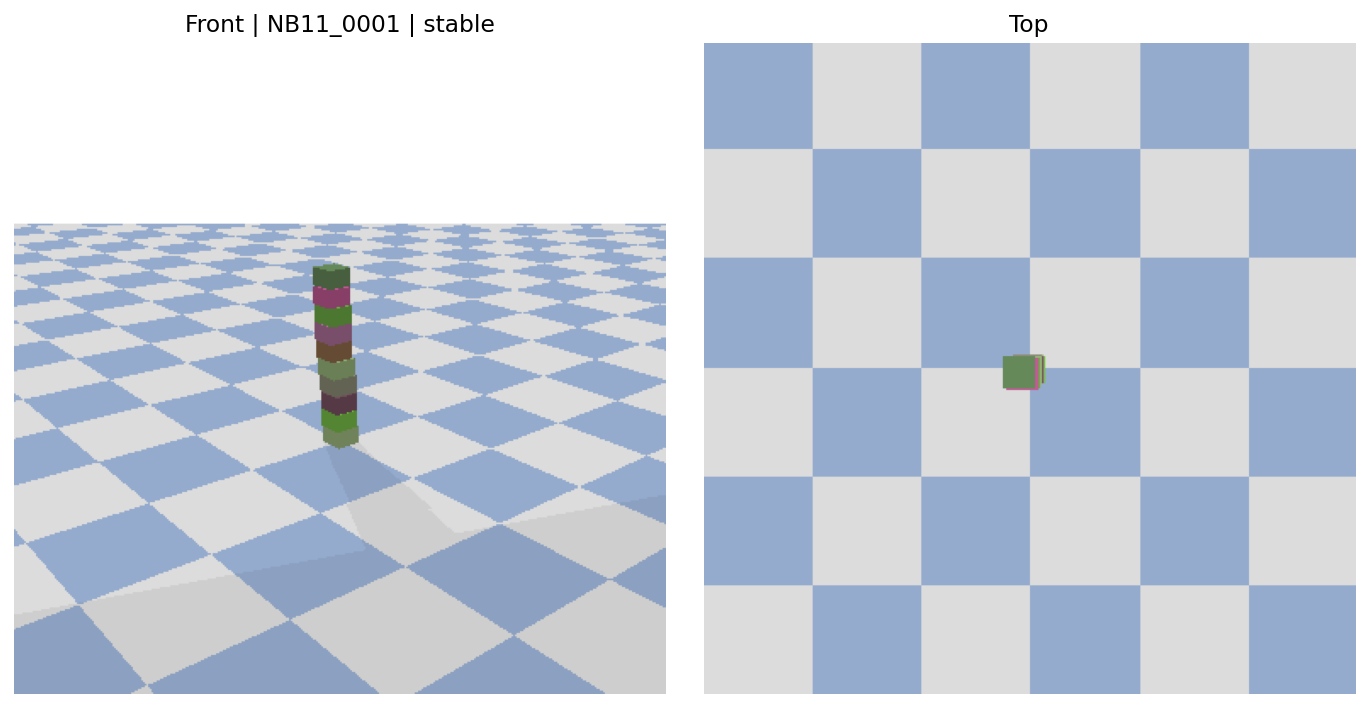

In [9]:
front_img = Image.open(front_path)
top_img = Image.open(top_path)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(front_img)
axes[0].set_title(f"Front | {meta['id']} | {meta['label']}")
axes[0].axis('off')

axes[1].imshow(top_img)
axes[1].set_title('Top')
axes[1].axis('off')

plt.tight_layout()
plt.show()

In [10]:
display(Video(filename=str(video_path), embed=True, html_attributes='controls loop'))

In [11]:
if 'layout_features' in meta:
    lf = pd.Series(meta['layout_features']).sort_index()
    display(lf.to_frame('value'))

,value
collapse_margin_proxy,0.348364
front_base_width_frac,0.083333
front_height_frac,0.526042
front_slenderness,4.809524
front_tilt,-0.022359
front_top_heaviness,0.500632
front_top_width_frac,0.093750
top_centroid_dx,-0.025109
top_centroid_dy,-0.015926
top_fill_ratio,0.957393
